<a href="https://colab.research.google.com/github/LarsVoermans/master-thesis-pead/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#All imports
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC

In [ ]:
from google.colab import files
uploaded = files.upload()  # er verschijnt een knop om bestanden te kiezen

Saving train_feature_engineered.parquet to train_feature_engineered.parquet
Saving val_feature_engineered.parquet to val_feature_engineered.parquet


In [ ]:
#Loading the dataset
train = pd.read_parquet("train_feature_engineered.parquet")
val = pd.read_parquet("val_feature_engineered.parquet")

In [ ]:

#All the price features which include values as medium and medium_low
valuation_features = [
    'Shillers Cyclically Adjusted P/E Ratio',
    'Enterprise Value Multiple',
    'Price/Book',
    'Price/Sales',
    'Price/Cash flow',
    'Price/Operating Earnings (Basic, Excl. EI)',
    'Price/Operating Earnings (Diluted, Excl. EI)',
    'P/E (Diluted, Excl. EI)',
    'P/E (Diluted, Incl. EI)',
    'Trailing P/E to Growth (PEG) ratio',
    'Book/Market',
    'Dividend Yield',
    'Dividend Payout Ratio'
]

# Select _Regime columns
regime_cols = [f"{col}_Regime" for col in valuation_features if f"{col}_Regime" in train.columns]

# Convert to string
for col in regime_cols:
    train[col] = train[col].astype(str)
    val[col] = val[col].astype(str)

# Missing values
for col in regime_cols:
    train[col] = train[col].replace("nan", "Missing")
    val[col] = val[col].replace("nan", "Missing")

# One-hot encoding (
train = pd.get_dummies(train, columns=regime_cols, drop_first=True)
val = pd.get_dummies(val, columns=regime_cols, drop_first=True)

# Align val and test on train columns
val = val.reindex(columns=train.columns, fill_value=0)


In [ ]:
#making 3 class return
# Train
conditions_train = [
    (train['Return'] > 3),
    (train['Return'] >= -3) & (train['Return'] <= 3),
    (train['Return'] < -3)
]

choices = [1, 0, -1]

train['Return_class_3'] = np.select(conditions_train, choices, default=np.nan)


# Validation
conditions_val = [
    (val['Return'] > 3),
    (val['Return'] >= -3) & (val['Return'] <= 3),
    (val['Return'] < -3)
]

val['Return_class_3'] = np.select(conditions_val, choices, default=np.nan)



In [ ]:
#making a return class
target = "Return"

X_train = train.drop(columns=["Return","Return_class","EPS_Estimate","EPS_Actual","Close_Before","Open_After","Return_class_3"])
y_train = train["Return_class_3"]

X_val = val.drop(columns=["Return","Return_class","EPS_Estimate","EPS_Actual","Close_Before","Open_After","Return_class_3"])
y_val = val["Return_class_3"]


In [ ]:
#dropping columns
drop_cols = [
    'CUSIP',
    'Global Company Key',
    'Historical CRSP PERMNO Link to COMPUSTAT Record',
    'Ticker',
    'Date',
    'EarningsDate',
    'Fiscal year end',
    'Fiscal quarter end',
    'Year',
    'Month'
]

X_train = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_val = X_val.drop(columns=[c for c in drop_cols if c in X_val.columns])


In [ ]:
#Making imputer
imputer = SimpleImputer(strategy='mean')

# Fit on training
X_train_scaled = imputer.fit_transform(X_train)

# Transform val
X_val_scaled = imputer.transform(X_val)


Start geoptimaliseerde LinearSVC op 11271 samples en 178 features...
[LibLinear]
--- Fold 1 Voltooid ---
Accuracy: 0.6452 | Macro F1: 0.2744
              precision    recall  f1-score   support

        -1.0       0.15      0.01      0.02       370
         0.0       0.65      0.98      0.78      1474
         1.0       0.33      0.01      0.02       411

    accuracy                           0.65      2255
   macro avg       0.38      0.33      0.27      2255
weighted avg       0.51      0.65      0.52      2255

[LibLinear]
--- Fold 2 Voltooid ---
Accuracy: 0.6446 | Macro F1: 0.2729
              precision    recall  f1-score   support

        -1.0       0.20      0.02      0.03       369
         0.0       0.65      0.98      0.78      1473
         1.0       0.12      0.00      0.00       412

    accuracy                           0.64      2254
   macro avg       0.33      0.33      0.27      2254
weighted avg       0.48      0.64      0.52      2254

[LibLinear]
--- Fold 3 Vo

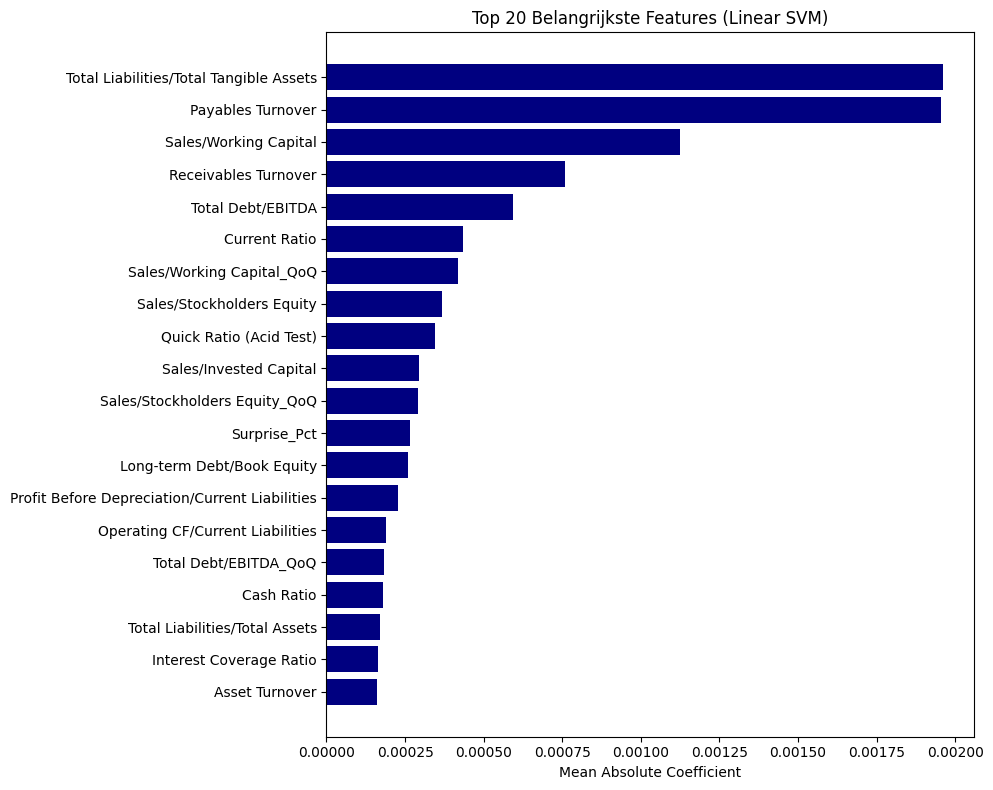

                                            Feature  Importance
35          Total Liabilities/Total Tangible Assets    0.001962
49                                Payables Turnover    0.001954
52                            Sales/Working Capital    0.001126
48                             Receivables Turnover    0.000760
27                                Total Debt/EBITDA    0.000595
44                                    Current Ratio    0.000434
108                       Sales/Working Capital_QoQ    0.000419
51                        Sales/Stockholders Equity    0.000367
43                          Quick Ratio (Acid Test)    0.000345
50                           Sales/Invested Capital    0.000294
107                   Sales/Stockholders Equity_QoQ    0.000292
0                                      Surprise_Pct    0.000266
36                       Long-term Debt/Book Equity    0.000259
31   Profit Before Depreciation/Current Liabilities    0.000227
32                 Operating CF/Current 

In [ ]:
# Modelling
X_full = np.vstack((X_train_scaled, X_val_scaled))
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

# 2. Setup For Stratified K-Fold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

svm_acc_list = []
svm_f1_list = []
svm_coef_list = []

print(f"Start geoptimaliseerde LinearSVC op {X_full.shape[0]} samples en {X_full.shape[1]} features...")

fold = 1
for train_index, test_index in skf.split(X_full, y_full):
    X_tr, X_te = X_full[train_index], X_full[test_index]
    y_tr, y_te = y_full.iloc[train_index], y_full.iloc[test_index]


    model_svm = LinearSVC(
        C=0.1,
        class_weight='balanced',
        random_state=42,
        dual=False,
        max_iter=5000,
        tol=1e-2,
        verbose=1
    )

    model_svm.fit(X_tr, y_tr)
    y_pred = model_svm.predict(X_te)

    # 4. Metrics
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='macro')

    svm_acc_list.append(acc)
    svm_f1_list.append(f1)
    svm_coef_list.append(np.mean(np.abs(model_svm.coef_), axis=0))

    print(f"\n--- Fold {fold} Voltooid ---")
    print(f"Accuracy: {acc:.4f} | Macro F1: {f1:.4f}")
    print(classification_report(y_te, y_pred))
    fold += 1

mean_svm_coefs = np.mean(svm_coef_list, axis=0)
svm_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': mean_svm_coefs
}).sort_values(by='Importance', ascending=False)

print("\n" + "="*30)
print(f"GEMIDDELDE SVM ACCURACY: {np.mean(svm_acc_list):.4f}")
print(f"GEMIDDELDE SVM MACRO F1: {np.mean(svm_f1_list):.4f}")
print("="*30)


plt.figure(figsize=(10, 8))
plt.barh(svm_importance['Feature'][:20], svm_importance['Importance'][:20], color='navy')
plt.gca().invert_yaxis()
plt.title('Top 20 Belangrijkste Features (Linear SVM)')
plt.xlabel('Mean Absolute Coefficient')
plt.tight_layout()
plt.show()

print(svm_importance.head(20))

Start geoptimaliseerde LinearSVC op 11271 samples en 22 features...
[LibLinear]
--- Fold 1 Voltooid ---
Accuracy: 0.6470 | Macro F1: 0.2703
              precision    recall  f1-score   support

        -1.0       0.19      0.01      0.03       370
         0.0       0.65      0.99      0.79      1474
         1.0       0.00      0.00      0.00       411

    accuracy                           0.65      2255
   macro avg       0.28      0.33      0.27      2255
weighted avg       0.46      0.65      0.52      2255

[LibLinear]
--- Fold 2 Voltooid ---
Accuracy: 0.6464 | Macro F1: 0.2701
              precision    recall  f1-score   support

        -1.0       0.14      0.01      0.02       369
         0.0       0.65      0.99      0.79      1473
         1.0       0.29      0.00      0.01       412

    accuracy                           0.65      2254
   macro avg       0.36      0.33      0.27      2254
weighted avg       0.50      0.65      0.52      2254

[LibLinear]
--- Fold 3 Vol

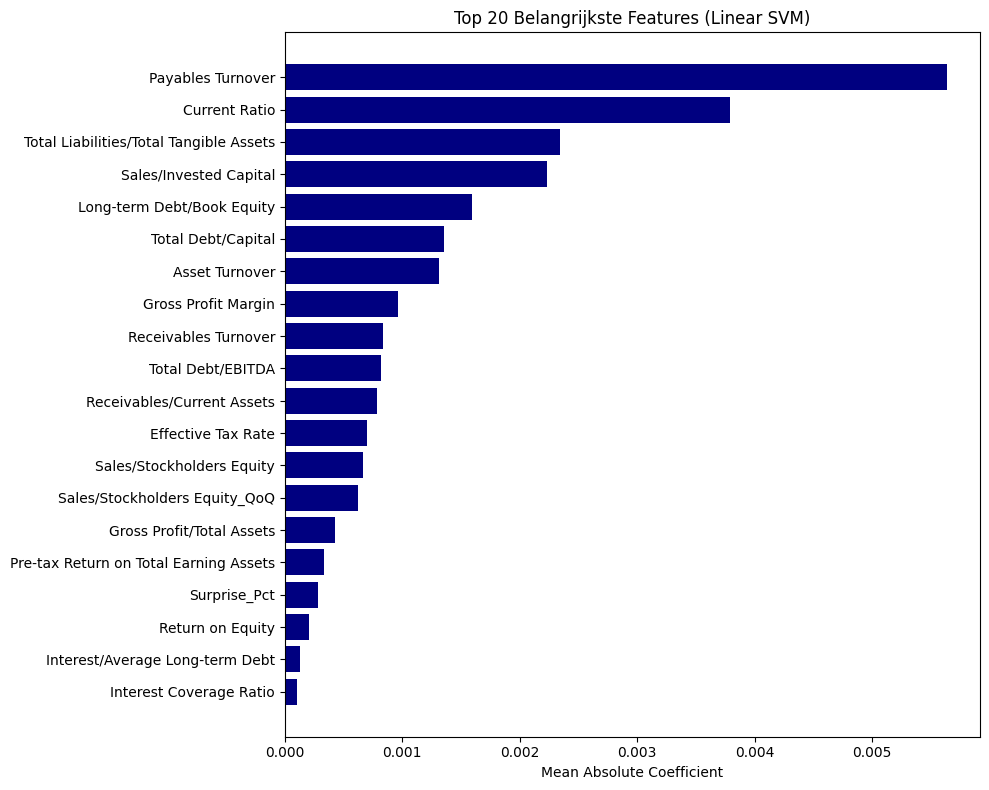

                                    Feature  Importance
2                         Payables Turnover    0.005639
7                             Current Ratio    0.003795
5   Total Liabilities/Total Tangible Assets    0.002346
8                    Sales/Invested Capital    0.002229
6                Long-term Debt/Book Equity    0.001594
18                       Total Debt/Capital    0.001355
21                           Asset Turnover    0.001313
13                      Gross Profit Margin    0.000963
20                     Receivables Turnover    0.000837
3                         Total Debt/EBITDA    0.000823
16               Receivables/Current Assets    0.000788
12                       Effective Tax Rate    0.000701
1                 Sales/Stockholders Equity    0.000661
4             Sales/Stockholders Equity_QoQ    0.000624
10                Gross Profit/Total Assets    0.000428
11   Pre-tax Return on Total Earning Assets    0.000336
0                              Surprise_Pct    0

In [ ]:
fundamental_29 = [
    "Surprise_Pct", "Sales/Stockholders Equity", "Payables Turnover",
    "Total Debt/EBITDA", "Sales/Stockholders Equity_QoQ",
    "Total Liabilities/Total Tangible Assets", "Long-term Debt/Book Equity",
    "Current Ratio", "Sales/Invested Capital", "Return on Equity",
    "Gross Profit/Total Assets", "Pre-tax Return on Total Earning Assets",
    "Effective Tax Rate", "Gross Profit Margin", "Interest/Average Long-term Debt",
    "Inventory Turnover", "Receivables/Current Assets",
    "Cash Conversion Cycle (Days)", "Total Debt/Capital",
    "Interest Coverage Ratio", "Receivables Turnover", "Asset Turnover"
]


feature_indices = [list(X_train.columns).index(f) for f in fundamental_29]
X_train_22 = X_train_scaled[:, feature_indices]
X_val_22 = X_val_scaled[:, feature_indices]

# Modelling
X_full = np.vstack((X_train_22, X_val_22))
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

# Setup For Stratified K-Fold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

svm_acc_list = []
svm_f1_list = []
svm_coef_list = []

print(f"Start geoptimaliseerde LinearSVC op {X_full.shape[0]} samples en {X_full.shape[1]} features...")

fold = 1
for train_index, test_index in skf.split(X_full, y_full):
    X_tr, X_te = X_full[train_index], X_full[test_index]
    y_tr, y_te = y_full.iloc[train_index], y_full.iloc[test_index]

    model_svm = LinearSVC(
        C=0.1,
        class_weight='balanced',
        random_state=42,
        dual=False,
        max_iter=5000,
        tol=1e-2,
        verbose=1
    )

    model_svm.fit(X_tr, y_tr)
    y_pred = model_svm.predict(X_te)

    # Metrics
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='macro')

    svm_acc_list.append(acc)
    svm_f1_list.append(f1)
    svm_coef_list.append(np.mean(np.abs(model_svm.coef_), axis=0))

    print(f"\n--- Fold {fold} Voltooid ---")
    print(f"Accuracy: {acc:.4f} | Macro F1: {f1:.4f}")
    print(classification_report(y_te, y_pred))
    fold += 1

mean_svm_coefs = np.mean(svm_coef_list, axis=0)
svm_importance = pd.DataFrame({
    'Feature': fundamental_29,
    'Importance': mean_svm_coefs
}).sort_values(by='Importance', ascending=False)

print("\n" + "="*30)
print(f"GEMIDDELDE SVM ACCURACY: {np.mean(svm_acc_list):.4f}")
print(f"GEMIDDELDE SVM MACRO F1: {np.mean(svm_f1_list):.4f}")
print("="*30)

plt.figure(figsize=(10, 8))
plt.barh(svm_importance['Feature'][:20], svm_importance['Importance'][:20], color='navy')
plt.gca().invert_yaxis()
plt.title('Top 20 Belangrijkste Features (Linear SVM)')
plt.xlabel('Mean Absolute Coefficient')
plt.tight_layout()
plt.show()

print(svm_importance.head(20))